# CNNとVision Transformerの違いを学ぶ実践教材

このノートブックでは，CNN（Convolutional Neural Network）とViT（Vision Transformer）の違いを，理論・実装・実験の3方向から確認します。

## 学習目標

- CNNとViTのアーキテクチャ上の違いを説明できる
- 畳み込み層とアテンション層のパラメータ数・計算量の違いを計算できる
- 小規模データセットでCNNとViTを同じ条件で比較できる
- モデルサイズ，性能，学習データ量，計算コストのトレードオフを考察できる

## 想定環境

- Python 3.10+
- PyTorch
- torchvision
- matplotlib
- pandas

GPUがある場合は自動で利用します。CPUでも動くように，実験はCIFAR-10の一部だけを使う設定にしています。

## 1. CNNとViTの基本的な考え方

| 観点 | CNN | ViT |
|---|---|---|
| 入力の扱い | 画像を2次元格子のまま処理 | 画像をパッチに分割し，トークン列として処理 |
| 主な演算 | 畳み込み | Multi-Head Self-Attention + MLP |
| 帰納バイアス | 局所性・平行移動等価性が強い | 位置関係は位置埋め込みから学習する |
| 長距離依存 | 層を重ねることで広げる | 1層のAttentionで全パッチ間を接続可能 |
| データ効率 | 小規模データでも比較的強い | 大規模データや事前学習で強みが出やすい |
| 計算量の特徴 | 画像サイズにおおむね線形 | トークン数に対してAttentionが二乗で増える |

CNNは「近くの画素から特徴を作り，深い層で大きな構造を捉える」設計です。ViTは「画像を単語列のようなトークン列に変換し，Self-Attentionで全トークン間の関係を学ぶ」設計です。

## 2. アーキテクチャの流れ

### CNNの典型例

```text
Image
  -> Conv + BN + ReLU
  -> Conv + BN + ReLU
  -> Pooling / Strided Conv
  -> ...
  -> Global Average Pooling
  -> Linear Classifier
```

### ViTの典型例

```text
Image
  -> Patchify
  -> Linear Projection / Conv Patch Embedding
  -> Add [CLS] token and positional embedding
  -> Transformer Encoder blocks
       - LayerNorm
       - Multi-Head Self-Attention
       - MLP
  -> Classifier Head
```

CNNでは特徴マップの空間構造を保ったまま処理します。ViTでは画像をパッチ単位に分け，それぞれをベクトル化して系列データとして扱います。

## 3. パラメータ数と計算量の基本式

### 畳み込み層

カーネルサイズを $K \times K$，入力チャネル数を $C_{in}$，出力チャネル数を $C_{out}$ とすると，畳み込み層のパラメータ数は次のようになります。

$$K^2 C_{in} C_{out} + C_{out}$$

出力特徴マップの高さ・幅を $H_{out}, W_{out}$ とすると，Multiply-Addのおおまかな回数は次のようになります。

$$H_{out} W_{out} K^2 C_{in} C_{out}$$

### Multi-Head Self-Attention層

埋め込み次元を $D$，トークン数を $N$ とします。標準的なSelf-Attentionでは，$Q,K,V$ の3つの線形変換と，出力の線形変換があります。バイアスを無視すると，パラメータ数はおおよそ次の通りです。

$$4D^2$$

Attention行列は $N \times N$ なので，Attention部分の計算量はおおよそ次のように増えます。

$$O(N^2D)$$

ViTではパッチサイズを小さくするとトークン数 $N$ が増え，Attentionの計算量が急増します。

In [1]:
import math
import random
from dataclasses import dataclass
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

seed = 42
random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 4. パラメータ数を手で計算する

まずは畳み込み層とSelf-Attention層のパラメータ数を関数で確認します。モデル全体を見る前に，基本部品の違いを定量的に押さえます。

### 図で見る畳み込み層のパラメータ

畳み込み層では，1つの出力チャネルを作るために，入力チャネルすべてにまたがる小さなカーネルを使います。出力チャネルが2つある場合は，このカーネルのセットを2組持ちます。

例として，入力がRGB画像なら $C_{in}=3$ です。カーネルサイズが $3 \times 3$ なら，1つの出力チャネルに必要な重みは次の個数です。

$$3 \times 3 \times 3 = 27$$

出力チャネルが2個なら，このカーネルのセットを2個持ちます。したがってバイアスを含めると，

$$3 \times 3 \times 3 \times 2 + 2 = 56$$

になります。重要なのは，カーネルは画像のすべての位置で共有されることです。画像が32x32でも224x224でも，層のパラメータ数そのものは変わりません。


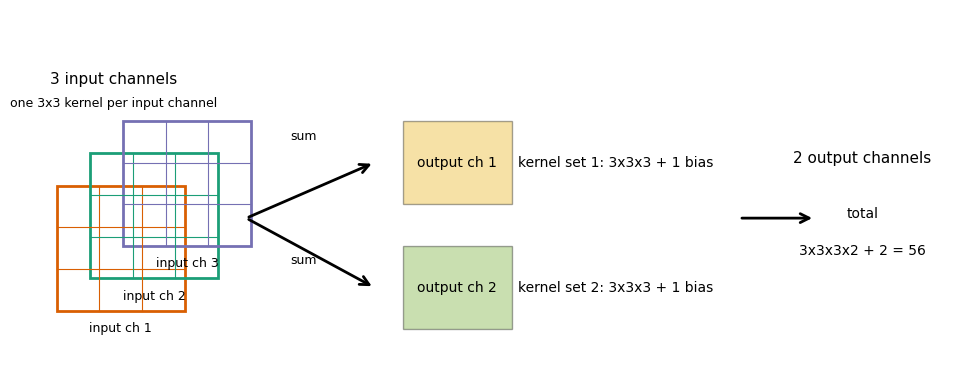

In [2]:
from matplotlib.patches import Rectangle, FancyArrowPatch


def draw_conv_parameter_diagram(kernel_size=3, in_channels=3, out_channels=2):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 4)
    ax.axis("off")

    colors = ["#d95f02", "#1b9e77", "#7570b3"]
    for c in range(in_channels):
        x0 = 0.45 + c * 0.35
        y0 = 0.75 + c * 0.35
        color = colors[c % len(colors)]
        ax.add_patch(Rectangle((x0, y0), 1.35, 1.35, fill=False, lw=2, ec=color))
        for i in range(1, kernel_size):
            ax.plot([x0, x0 + 1.35], [y0 + i * 1.35 / kernel_size] * 2, color=color, lw=0.8)
            ax.plot([x0 + i * 1.35 / kernel_size] * 2, [y0, y0 + 1.35], color=color, lw=0.8)
        ax.text(x0 + 0.675, y0 - 0.23, f"input ch {c+1}", ha="center", fontsize=9)

    ax.text(1.05, 3.2, f"{in_channels} input channels", ha="center", fontsize=11)
    ax.text(1.05, 2.95, f"one {kernel_size}x{kernel_size} kernel per input channel", ha="center", fontsize=9)

    for out_idx in range(out_channels):
        y = 2.35 - out_idx * 1.35
        color = ["#e6ab02", "#66a61e"][out_idx % 2]
        ax.add_patch(FancyArrowPatch((2.45, 1.75), (3.8, y), arrowstyle="->", mutation_scale=16, lw=2))
        ax.text(3.05, y + 0.25, "sum", ha="center", fontsize=9)
        ax.add_patch(Rectangle((4.1, y - 0.45), 1.15, 0.9, fill=True, color=color, alpha=0.35, ec="black"))
        ax.text(4.675, y, f"output ch {out_idx + 1}", ha="center", va="center", fontsize=10)
        ax.text(6.35, y, f"kernel set {out_idx + 1}: {kernel_size}x{kernel_size}x{in_channels} + 1 bias", ha="center", va="center", fontsize=10)

    ax.add_patch(FancyArrowPatch((7.65, 1.75), (8.45, 1.75), arrowstyle="->", mutation_scale=16, lw=2))
    ax.text(8.95, 2.35, f"{out_channels} output channels", ha="center", fontsize=11)
    total = kernel_size * kernel_size * in_channels * out_channels + out_channels
    ax.text(8.95, 1.75, f"total", ha="center", fontsize=10)
    ax.text(8.95, 1.35, f"{kernel_size}x{kernel_size}x{in_channels}x{out_channels} + {out_channels} = {total}", ha="center", fontsize=10)
    plt.tight_layout()


draw_conv_parameter_diagram(kernel_size=3, in_channels=3, out_channels=2)


### 図で見るMHSAのパラメータ

Self-Attentionでは，入力トークン列 $X \in \mathbb{R}^{N \times D}$ を，Query，Key，Valueに変換します。各変換は $D \times D$ の線形層です。

- $W_Q$: Queryを作る
- $W_K$: Keyを作る
- $W_V$: Valueを作る
- $W_O$: Attention後の出力をもう一度混ぜる

Multi-Head Self-Attentionでは，Q,K,Vの $D$ 次元をヘッド数で分割します。たとえば $D=128$，ヘッド数が4なら，1ヘッドあたりの次元は $128 / 4 = 32$ です。

重要なのは，ヘッドに分ける前に $W_Q,W_K,W_V$ で全体として $N \times D$ を作り，それを $N \times 4 \times 32$ のように並べ替えて使うことです。つまり，ヘッド数を4にしても，$D$ を固定している限りQ,K,Vの線形層の重み数は基本的に増えません。

そのため，バイアスを無視するとMHSAの主なパラメータ数は，

$$D^2 + D^2 + D^2 + D^2 = 4D^2$$

です。各ヘッドは自分の $32$ 次元ぶんのQ,K,VでAttentionを計算し，最後に4ヘッドぶんを連結して $N \times D$ に戻してから，出力射影 $W_O$ を通します。

### なぜheadに分けるのか

Headに分ける主な理由は，計算量を減らすことだけではありません。より重要なのは，同じトークン列を複数の異なる部分空間から見ることです。

たとえば $D=128$，ヘッド数が4なら，1ヘッドあたりの次元は $32$ です。各headは別々の $32$ 次元ぶんのQ,K,Vを使ってAttentionを計算します。イメージとしては，あるheadは局所的な形，別のheadは離れたパッチの対応，別のheadは背景との関係，というように，異なる関係性を学習できます。

計算量については，$D$ を固定しているなら大きくは変わりません。各headのAttention計算はおおよそ $N^2 \times (D / h)$ で，これを $h$ 個足すと，

$$h \times N^2 \times \frac{D}{h} = N^2D$$

になります。つまり，1つのheadだけを見ると軽くなりますが，head数ぶん計算するため，全体のAttention計算量はおおよそ同じです。


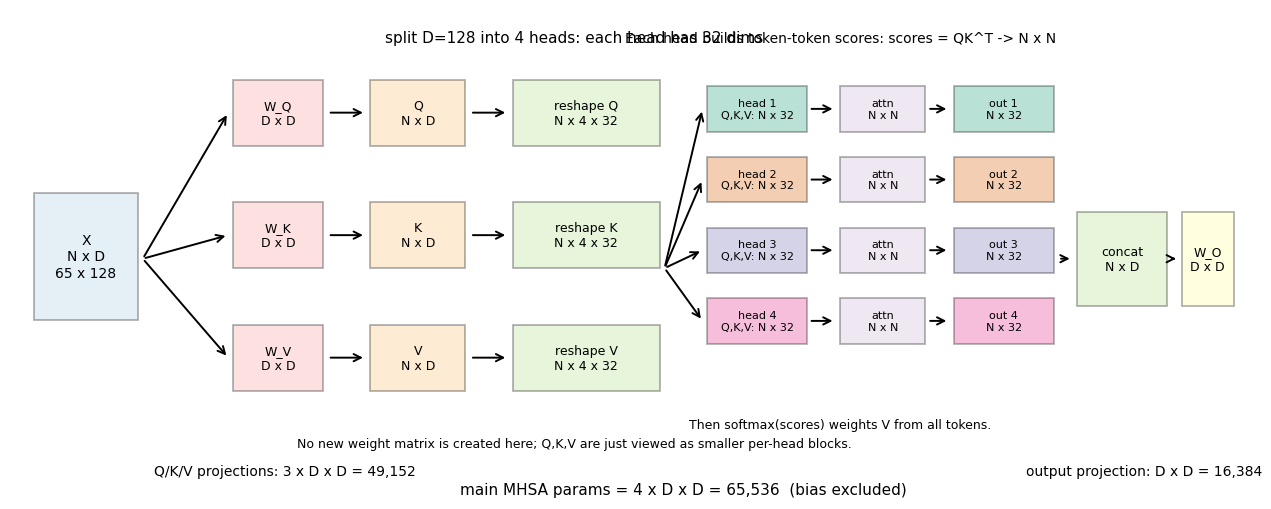

In [3]:
from matplotlib.patches import Rectangle, FancyArrowPatch


def draw_mhsa_parameter_diagram(embed_dim=128, num_heads=4, num_tokens=65):
    head_dim = embed_dim // num_heads
    fig, ax = plt.subplots(figsize=(13, 5.2))
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 5.2)
    ax.axis("off")

    def box(x, y, w, h, label, color, fontsize=9):
        ax.add_patch(Rectangle((x, y), w, h, fill=True, color=color, alpha=0.30, ec="black", lw=1.3))
        ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=fontsize)

    def arrow(x1, y1, x2, y2):
        ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->", mutation_scale=13, lw=1.4))

    box(0.25, 1.9, 1.1, 1.35, f"X\nN x D\n{num_tokens} x {embed_dim}", "#a6cee3", 10)

    qkv_y = [3.75, 2.45, 1.15]
    for y, name in zip(qkv_y, ["Q", "K", "V"]):
        arrow(1.4, 2.55, 2.3, y + 0.35)
        box(2.35, y, 0.95, 0.7, f"W_{name}\nD x D", "#fb9a99")
        arrow(3.35, y + 0.35, 3.75, y + 0.35)
        box(3.8, y, 1.0, 0.7, f"{name}\nN x D", "#fdbf6f")
        arrow(4.85, y + 0.35, 5.25, y + 0.35)
        box(5.3, y, 1.55, 0.7, f"reshape {name}\nN x {num_heads} x {head_dim}", "#b2df8a")

    ax.text(5.95, 4.85, f"split D={embed_dim} into {num_heads} heads: each head has {head_dim} dims", ha="center", fontsize=11)
    ax.text(5.95, 0.55, "No new weight matrix is created here; Q,K,V are just viewed as smaller per-head blocks.", ha="center", fontsize=9)
    ax.text(8.75, 4.85, "Each head builds token-token scores: scores = QK^T -> N x N", ha="center", fontsize=10)
    ax.text(8.75, 0.75, "Then softmax(scores) weights V from all tokens.", ha="center", fontsize=9)

    head_colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]
    for h in range(num_heads):
        y = 3.9 - h * 0.75
        box(7.35, y, 1.05, 0.48, f"head {h+1}\nQ,K,V: N x {head_dim}", head_colors[h % len(head_colors)], 8)
        box(8.75, y, 0.9, 0.48, f"attn\nN x N", "#cab2d6", 8)
        box(9.95, y, 1.05, 0.48, f"out {h+1}\nN x {head_dim}", head_colors[h % len(head_colors)], 8)
        arrow(6.9, 2.45, 7.3, y + 0.24)
        arrow(8.42, y + 0.24, 8.7, y + 0.24)
        arrow(9.67, y + 0.24, 9.9, y + 0.24)

    box(11.25, 2.05, 0.95, 1.0, f"concat\nN x D", "#b2df8a", 9)
    arrow(11.05, 2.55, 11.2, 2.55)
    box(12.35, 2.05, 0.55, 1.0, f"W_O\nD x D", "#ffff99", 9)
    arrow(12.22, 2.55, 12.32, 2.55)

    qkv_params = 3 * embed_dim * embed_dim
    out_params = embed_dim * embed_dim
    total = qkv_params + out_params
    ax.text(2.9, 0.25, f"Q/K/V projections: 3 x D x D = {qkv_params:,}", ha="center", fontsize=10)
    ax.text(11.95, 0.25, f"output projection: D x D = {out_params:,}", ha="center", fontsize=10)
    ax.text(7.1, 0.05, f"main MHSA params = 4 x D x D = {total:,}  (bias excluded)", ha="center", fontsize=11)
    plt.tight_layout()

draw_mhsa_parameter_diagram(embed_dim=128, num_heads=4, num_tokens=65)


In [4]:
def conv2d_params(kernel_size, in_channels, out_channels, bias=True):
    params = kernel_size * kernel_size * in_channels * out_channels
    if bias:
        params += out_channels
    return params


def mhsa_params(embed_dim, bias=True):
    # q, k, v projection + output projection
    params = 4 * embed_dim * embed_dim
    if bias:
        params += 4 * embed_dim
    return params


def conv2d_madds(h, w, kernel_size, in_channels, out_channels):
    return h * w * kernel_size * kernel_size * in_channels * out_channels


def mhsa_madds(num_tokens, embed_dim):
    # Very rough estimate: qkv projections + attention scores + weighted sum + output projection.
    projection = 4 * num_tokens * embed_dim * embed_dim
    attention = 2 * num_tokens * num_tokens * embed_dim
    return projection + attention


rows = []
for d in [64, 128, 256, 512]:
    rows.append({
        "layer": f"MHSA D={d}",
        "params": mhsa_params(d),
        "rough_madds_N65": mhsa_madds(65, d),
    })

for c in [64, 128, 256, 512]:
    rows.append({
        "layer": f"Conv 3x3 C_in=C_out={c}",
        "params": conv2d_params(3, c, c),
        "rough_madds_32x32": conv2d_madds(32, 32, 3, c, c),
    })

pd.DataFrame(rows)

,layer,params,rough_madds_N65,rough_madds_32x32
0,MHSA D=64,16640,1605760.0,NaN
1,MHSA D=128,66048,5341440.0,NaN
2,MHSA D=256,263168,19202560.0,NaN
3,MHSA D=512,1050624,72483840.0,NaN
4,Conv 3x3 C_in=C_out=64,36928,NaN,3.774874e+07
5,Conv 3x3 C_in=C_out=128,147584,NaN,1.509949e+08
6,Conv 3x3 C_in=C_out=256,590080,NaN,6.039798e+08
7,Conv 3x3 C_in=C_out=512,2359808,NaN,2.415919e+09


### 考察

- 畳み込み層のパラメータ数はカーネルサイズ，入力チャネル，出力チャネルで決まります。
- MHSAのパラメータ数は主に埋め込み次元 $D$ の二乗で増えます。
- MHSAの計算量はトークン数 $N$ の二乗にも依存します。画像解像度を上げる，またはパッチサイズを小さくすると急に重くなります。
- 畳み込みの計算量は空間サイズ $H \times W$ に依存しますが，局所カーネルなので全画素対の関係は直接計算しません。

## 5. パッチサイズとトークン数の関係

ViTの計算コストを理解するうえで，パッチサイズは重要です。例えば32x32画像を4x4パッチに分けると，8x8=64個の画像トークンになります。分類用の[CLS]トークンを足すと65トークンです。

In [5]:
def vit_token_count(image_size, patch_size, use_cls_token=True):
    patches_per_side = image_size // patch_size
    n = patches_per_side * patches_per_side
    return n + int(use_cls_token)


patch_rows = []
for image_size in [32, 64, 128, 224]:
    for patch_size in [4, 8, 16, 32]:
        if image_size % patch_size == 0:
            n = vit_token_count(image_size, patch_size)
            patch_rows.append({
                "image_size": image_size,
                "patch_size": patch_size,
                "tokens_with_cls": n,
                "attention_matrix_entries": n * n,
            })

pd.DataFrame(patch_rows)

,image_size,patch_size,tokens_with_cls,attention_matrix_entries
0,32,4,65,4225
1,32,8,17,289
2,32,16,5,25
3,32,32,2,4
4,64,4,257,66049
5,64,8,65,4225
6,64,16,17,289
7,64,32,5,25
8,128,4,1025,1050625
9,128,8,257,66049


## 6. 直感的な違い: 局所処理と全体処理

CNNの畳み込みは，最初は近傍の画素だけを見ます。深くなるほど受容野が広がります。一方，ViTのSelf-Attentionは，最初のTransformer層からすべてのパッチ同士の関係を計算できます。

ただし，この「最初から全体を見られる」性質は無料ではありません。トークン数が増えるとAttention行列が大きくなるため，計算量とメモリ使用量が増えます。

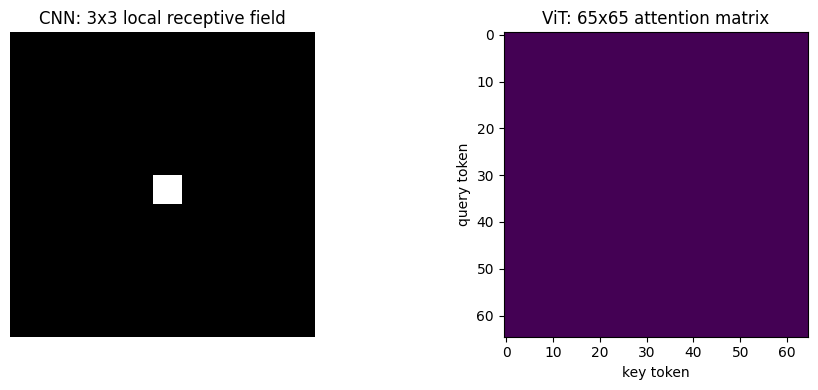

In [70]:
image_size = 32
patch_size = 4
num_tokens = vit_token_count(image_size, patch_size)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

grid = torch.zeros(image_size, image_size)
center = image_size // 2
grid[center - 1:center + 2, center - 1:center + 2] = 1.0
axes[0].imshow(grid, cmap="gray")
axes[0].set_title("CNN: 3x3 local receptive field")
axes[0].axis("off")

attn = torch.ones(num_tokens, num_tokens)
axes[1].imshow(attn, cmap="viridis")
axes[1].set_title(f"ViT: {num_tokens}x{num_tokens} attention matrix")
axes[1].set_xlabel("key token")
axes[1].set_ylabel("query token")

plt.tight_layout()

## 7. 実験用モデルを実装する

ここではCIFAR-10向けに，小さなCNNと小さなViTを実装します。目的は最高精度を出すことではなく，同じデータ・同じ学習ループで，モデル構造の違いを観察することです。

In [6]:
class TinyCNN(nn.Module):
    def __init__(self, num_classes=10, width=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, width, 3, padding=1),
            nn.BatchNorm2d(width),
            nn.ReLU(inplace=True),
            nn.Conv2d(width, width, 3, padding=1),
            nn.BatchNorm2d(width),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(width, width * 2, 3, padding=1),
            nn.BatchNorm2d(width * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(width * 2, width * 2, 3, padding=1),
            nn.BatchNorm2d(width * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(width * 2, width * 4, 3, padding=1),
            nn.BatchNorm2d(width * 4),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(width * 4, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        b, n, d = x.shape
        qkv = self.qkv(x).reshape(b, n, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = scores.softmax(dim=-1)
        attn = self.dropout(attn)
        out = attn @ v
        out = out.transpose(1, 2).reshape(b, n, d)
        out = self.proj(out)
        if return_attention:
            return out, attn
        return out


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        hidden_dim = embed_dim * mlp_ratio
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class TinyViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4, num_classes=10, dropout=0.0):
        super().__init__()
        assert image_size % patch_size == 0
        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (image_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[
            TransformerEncoderBlock(embed_dim, num_heads, dropout=dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        x = self.blocks(x)
        x = self.norm(x)
        return self.head(x[:, 0])

## 8. モデルサイズを比較する

同じ分類タスクでも，CNNとViTではパラメータの使われ方が異なります。ViTではAttentionだけでなく，MLP部分も多くのパラメータを持ちます。

ここではCNNとViTを1つずつではなく，サイズや設定を変えた複数の候補として並べます。パラメータ数だけでなく，局所性，全体を見る性質，patchサイズによる計算量の違いも一緒に確認します。


In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_table(model_specs):
    rows = []
    for spec in model_specs:
        params = count_parameters(spec["model"])
        rows.append({
            "model": spec["name"],
            "family": spec["family"],
            "trainable_params": params,
            "params_million": params / 1e6,
            "size": spec["size"],
            "main_property": spec["main_property"],
            "cost_note": spec["cost_note"],
        })
    return pd.DataFrame(rows)


model_specs = [
    {
        "name": "TinyCNN width=16",
        "family": "CNN",
        "model": TinyCNN(width=16),
        "size": "small",
        "main_property": "local convolution bias; lightweight",
        "cost_note": "cost grows with H x W and channel width",
    },
    {
        "name": "TinyCNN width=32",
        "family": "CNN",
        "model": TinyCNN(width=32),
        "size": "medium",
        "main_property": "stronger local feature extractor",
        "cost_note": "more channels increase conv parameters",
    },
    {
        "name": "TinyCNN width=64",
        "family": "CNN",
        "model": TinyCNN(width=64),
        "size": "large",
        "main_property": "larger local representation capacity",
        "cost_note": "conv cost rises with channel width",
    },
    {
        "name": "TinyViT D=32 depth=2 patch=4",
        "family": "ViT",
        "model": TinyViT(embed_dim=32, depth=2, num_heads=4, patch_size=4),
        "size": "small",
        "main_property": "global token mixing with low D",
        "cost_note": "attention uses 65 x 65 token matrix",
    },
    {
        "name": "TinyViT D=64 depth=2 patch=4",
        "family": "ViT",
        "model": TinyViT(embed_dim=64, depth=2, num_heads=4, patch_size=4),
        "size": "medium",
        "main_property": "global token mixing; shallower encoder",
        "cost_note": "fewer blocks reduce repeated attention/MLP cost",
    },
    {
        "name": "TinyViT D=64 depth=4 patch=4",
        "family": "ViT",
        "model": TinyViT(embed_dim=64, depth=4, num_heads=4, patch_size=4),
        "size": "large-depth",
        "main_property": "more repeated global mixing",
        "cost_note": "depth repeats attention and MLP blocks",
    },
    {
        "name": "TinyViT D=64 depth=4 patch=8",
        "family": "ViT",
        "model": TinyViT(embed_dim=64, depth=4, num_heads=4, patch_size=8),
        "size": "large-token-light",
        "main_property": "fewer tokens; coarser patches",
        "cost_note": "attention uses 17 x 17 token matrix",
    },
]

size_table = model_size_table(model_specs)
size_table


,model,family,trainable_params,params_million,size,main_property,cost_note
0,TinyCNN width=16,CNN,36122,0.036122,small,local convolution bias; lightweight,cost grows with H x W and channel width
1,TinyCNN width=32,CNN,141354,0.141354,medium,stronger local feature extractor,more channels increase conv parameters
2,TinyCNN width=64,CNN,559178,0.559178,large,larger local representation capacity,conv cost rises with channel width
3,TinyViT D=32 depth=2 patch=4,ViT,29482,0.029482,small,global token mixing with low D,attention uses 65 x 65 token matrix
4,TinyViT D=64 depth=2 patch=4,ViT,108106,0.108106,medium,global token mixing; shallower encoder,fewer blocks reduce repeated attention/MLP cost
5,TinyViT D=64 depth=4 patch=4,ViT,208074,0.208074,large-depth,more repeated global mixing,depth repeats attention and MLP blocks
6,TinyViT D=64 depth=4 patch=8,ViT,214218,0.214218,large-token-light,fewer tokens; coarser patches,attention uses 17 x 17 token matrix


## 9. CIFAR-10で小規模比較実験

ここからは実際に学習させます。配布時に実行しやすいよう，初期設定では学習データを一部だけ使います。精度を上げたい場合は `train_subset_size` や `epochs` を増やしてください。

このノートブックでは，ローカルに配置済みの `~/local/datasets/cifar-10/cifar-10` を使います。`train.csv` / `test.csv` と `images/*.png` から読み込むため，ネットワークからのダウンロードは行いません。


In [73]:
batch_size = 128
train_subset_size = 5000
test_subset_size = 1000
epochs = 10

cifar10_root = Path("~/local/datasets/cifar-10/cifar-10").expanduser()
cifar10_images = cifar10_root / "images"


class LocalCIFAR10(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.items = pd.read_csv(csv_file)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        row = self.items.iloc[idx]
        image_path = self.image_dir / row["filename"]
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = int(row["label"])
        return image, label


transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

def balanced_subset_indices(items, subset_size, seed=42):
    subset_size = min(subset_size, len(items))
    rng = random.Random(seed)
    labels = sorted(items["label"].unique())
    base = subset_size // len(labels)
    remainder = subset_size % len(labels)
    indices = []
    for label_index, label in enumerate(labels):
        label_indices = items.index[items["label"] == label].tolist()
        rng.shuffle(label_indices)
        take = base + int(label_index < remainder)
        indices.extend(label_indices[:take])
    rng.shuffle(indices)
    return indices


# Alternative: use torchvision's built-in CIFAR-10 loader.
# Uncomment this block if you want torchvision to manage the dataset.
# It expects the standard cifar-10-batches-py format under root, or downloads it when download=True.
#
# torchvision_root = Path("./data")
# train_dataset = datasets.CIFAR10(root=torchvision_root, train=True, download=True, transform=transform_train)
# test_dataset = datasets.CIFAR10(root=torchvision_root, train=False, download=True, transform=transform_test)
# train_indices = balanced_subset_indices(pd.DataFrame({"label": train_dataset.targets}), train_subset_size, seed=seed)
# test_indices = balanced_subset_indices(pd.DataFrame({"label": test_dataset.targets}), test_subset_size, seed=seed)
# train_subset = Subset(train_dataset, train_indices)
# test_subset = Subset(test_dataset, test_indices)
#
# Current default: use the local CSV + PNG dataset below.

train_dataset = LocalCIFAR10(cifar10_root / "train.csv", cifar10_images, transform=transform_train)
test_dataset = LocalCIFAR10(cifar10_root / "test.csv", cifar10_images, transform=transform_test)



train_indices = balanced_subset_indices(train_dataset.items, train_subset_size, seed=seed)
test_indices = balanced_subset_indices(test_dataset.items, test_subset_size, seed=seed)
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

len(train_subset), len(test_subset), cifar10_root


(5000, 1000, PosixPath('/home/usrs/katsu8/local/datasets/cifar-10/cifar-10'))

In [74]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


def fit_model(name, model, epochs=3, lr=3e-4, weight_decay=0.05, train_loader_arg=None, test_loader_arg=None):
    model = model.to(device)
    current_train_loader = train_loader if train_loader_arg is None else train_loader_arg
    current_test_loader = test_loader if test_loader_arg is None else test_loader_arg
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, current_train_loader, optimizer, criterion)
        test_loss, test_acc = evaluate(model, current_test_loader, criterion)
        row = {
            "model": name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "params": count_parameters(model),
        }
        history.append(row)
        print(row)
    return pd.DataFrame(history)

In [75]:
experiment_models = {spec["name"]: spec["model"] for spec in model_specs}

histories = []
for name, model in experiment_models.items():
    histories.append(fit_model(name, model, epochs=epochs))

results = pd.concat(histories, ignore_index=True)
result_display = results[results["epoch"] == epochs].copy()
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(result_display)


{'model': 'TinyCNN width=16', 'epoch': 1, 'train_loss': 2.152602407836914, 'train_acc': 0.2132, 'test_loss': 2.1027009201049807, 'test_acc': 0.195, 'params': 36122}
{'model': 'TinyCNN width=16', 'epoch': 2, 'train_loss': 1.9762356678009034, 'train_acc': 0.2958, 'test_loss': 1.907532943725586, 'test_acc': 0.317, 'params': 36122}
{'model': 'TinyCNN width=16', 'epoch': 3, 'train_loss': 1.888581039428711, 'train_acc': 0.3282, 'test_loss': 1.8296254558563232, 'test_acc': 0.352, 'params': 36122}
{'model': 'TinyCNN width=16', 'epoch': 4, 'train_loss': 1.8001786590576172, 'train_acc': 0.3678, 'test_loss': 1.7510459146499633, 'test_acc': 0.364, 'params': 36122}
{'model': 'TinyCNN width=16', 'epoch': 5, 'train_loss': 1.7354529218673707, 'train_acc': 0.3862, 'test_loss': 1.6978965435028077, 'test_acc': 0.368, 'params': 36122}
{'model': 'TinyCNN width=16', 'epoch': 6, 'train_loss': 1.6874469253540039, 'train_acc': 0.4038, 'test_loss': 1.6838902492523193, 'test_acc': 0.38, 'params': 36122}
{'model'

,model,epoch,train_loss,train_acc,test_loss,test_acc,params
9,TinyCNN width=16,10,1.518842,0.4658,1.497191,0.461,36122
19,TinyCNN width=32,10,1.301296,0.5552,1.373819,0.484,141354
29,TinyCNN width=64,10,1.144706,0.5982,1.188064,0.574,559178
39,TinyViT D=32 depth=2 patch=4,10,1.756565,0.3436,1.816044,0.321,29482
49,TinyViT D=64 depth=2 patch=4,10,1.659009,0.3798,1.672185,0.376,108106
59,TinyViT D=64 depth=4 patch=4,10,1.625092,0.4002,1.672395,0.381,208074
69,TinyViT D=64 depth=4 patch=8,10,1.724217,0.3668,1.773339,0.339,214218


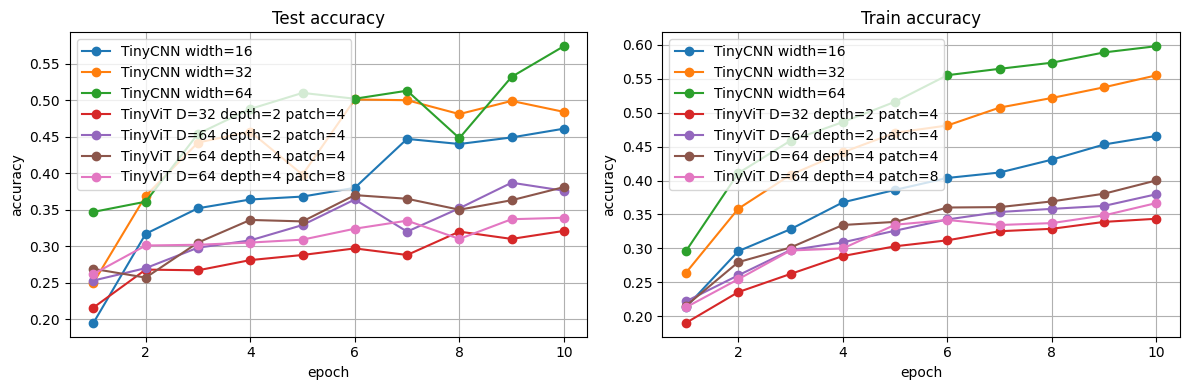

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, group in results.groupby("model"):
    axes[0].plot(group["epoch"], group["test_acc"], marker="o", label=name)
    axes[1].plot(group["epoch"], group["train_acc"], marker="o", label=name)

axes[0].set_title("Test accuracy")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("accuracy")
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("Train accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()

## 10. サイズと性能のトレードオフ

次のセルでは，最後のエポックの精度とパラメータ数を散布図にします。CNNとViTを複数点ずつ並べることで，単に大きいモデルが良いのか，CNN/ViTの性質やpatchサイズの違いが効いているのかを見やすくします。

右上に行くほど「大きくて高精度」，左上に行くほど「小さくて高精度」です。点の色はモデル family を表します。


,model,family,size,params,params_million,test_acc,main_property,cost_note
0,TinyCNN width=16,CNN,small,36122,0.036122,0.461,local convolution bias; lightweight,cost grows with H x W and channel width
1,TinyViT D=64 depth=4 patch=4,ViT,large-depth,208074,0.208074,0.381,more repeated global mixing,depth repeats attention and MLP blocks
2,TinyViT D=64 depth=2 patch=4,ViT,medium,108106,0.108106,0.376,global token mixing; shallower encoder,fewer blocks reduce repeated attention/MLP cost
3,TinyViT D=32 depth=2 patch=4,ViT,small,29482,0.029482,0.321,global token mixing with low D,attention uses 65 x 65 token matrix
4,TinyCNN width=64,CNN,large,559178,0.559178,0.574,larger local representation capacity,conv cost rises with channel width
5,TinyCNN width=32,CNN,medium,141354,0.141354,0.484,stronger local feature extractor,more channels increase conv parameters
6,TinyViT D=64 depth=4 patch=8,ViT,large-token-light,214218,0.214218,0.339,fewer tokens; coarser patches,attention uses 17 x 17 token matrix


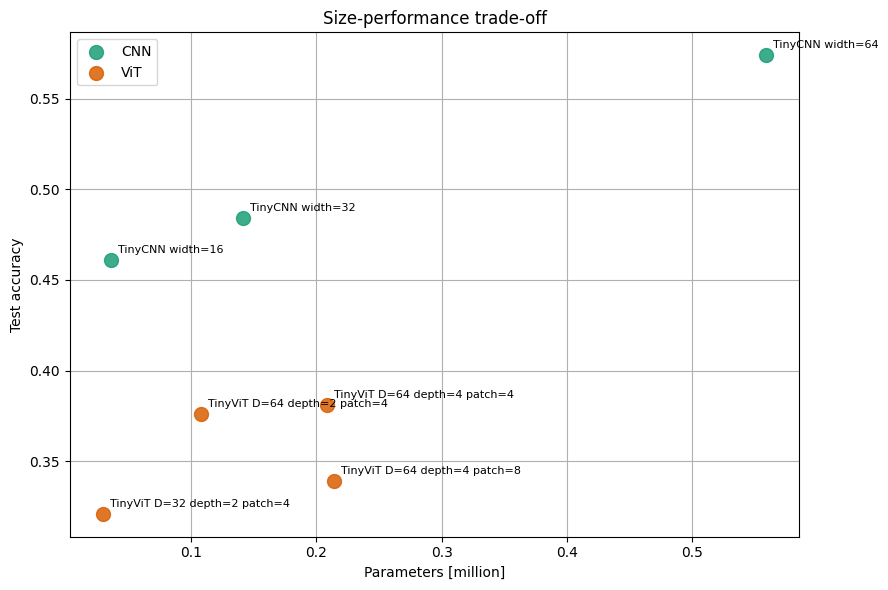

In [77]:
final_results = results.sort_values("epoch").groupby("model").tail(1).copy()
final_results = final_results.merge(
    size_table[["model", "family", "size", "main_property", "cost_note"]],
    on="model",
    how="left",
)
final_results["params_million"] = final_results["params"] / 1e6

fig, ax = plt.subplots(figsize=(9, 6))
colors = {"CNN": "#1b9e77", "ViT": "#d95f02"}
for family, group in final_results.groupby("family"):
    ax.scatter(
        group["params_million"],
        group["test_acc"],
        s=100,
        label=family,
        color=colors.get(family, "#7570b3"),
        alpha=0.85,
    )
    for _, row in group.iterrows():
        ax.annotate(row["model"], (row["params_million"], row["test_acc"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("Parameters [million]")
ax.set_ylabel("Test accuracy")
ax.set_title("Size-performance trade-off")
ax.grid(True)
ax.legend()
plt.tight_layout()

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None):
    display(final_results[["model", "family", "size", "params", "params_million", "test_acc", "main_property", "cost_note"]])


## 11. Attentionを可視化する

ViTの特徴は，各トークンが他のトークンをどの程度参照しているかをAttention行列として観察できる点です。以下では，未学習または学習済みモデルの最初のブロックからAttentionを取り出します。

この可視化は解釈の出発点として有用ですが，Attentionの値をそのまま「モデルの理由」と断定するのは危険です。あくまで内部表現を観察する一つの手段として扱います。

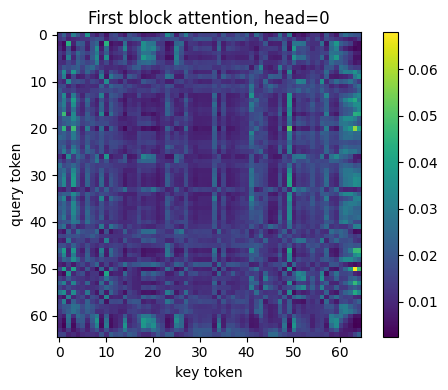

In [78]:
@torch.no_grad()
def visualize_first_block_attention(model, loader, head=0):
    model.eval()
    x, y = next(iter(loader))
    x = x[:1].to(device)

    patch_tokens = model.patch_embed(x).flatten(2).transpose(1, 2)
    cls = model.cls_token.expand(patch_tokens.size(0), -1, -1)
    tokens = torch.cat([cls, patch_tokens], dim=1) + model.pos_embed

    block = model.blocks[0]
    _, attn = block.attn(block.norm1(tokens), return_attention=True)
    attn_map = attn[0, head].detach().cpu()

    plt.figure(figsize=(5, 4))
    plt.imshow(attn_map, cmap="viridis")
    plt.title(f"First block attention, head={head}")
    plt.xlabel("key token")
    plt.ylabel("query token")
    plt.colorbar()
    plt.tight_layout()


vit_for_attention = TinyViT(embed_dim=64, depth=4, num_heads=4, patch_size=4).to(device)
visualize_first_block_attention(vit_for_attention, test_loader, head=0)

## 12. Patch sizeが変えるもの: トークン数と計算量

Patch sizeはViTの性能と計算量の両方に効きます。ただし，短いepochでpatch sizeごとの精度を比べると，まだ収束しておらず順位が不安定になりやすいです。

そのため，ここではまずpatch sizeがトークン数とAttention行列サイズをどう変えるかだけ確認します。実際に学習して比較する実験は，後の「条件別実験」に統合し，patch size比較だけ長めのepochで実行できるようにします。


In [82]:
patch_experiment_configs = [
    {"patch_size": 4, "embed_dim": 64, "depth": 4, "num_heads": 4},
    {"patch_size": 8, "embed_dim": 64, "depth": 4, "num_heads": 4},
    {"patch_size": 16, "embed_dim": 64, "depth": 4, "num_heads": 4},
]

patch_summary_rows = []
for cfg in patch_experiment_configs:
    patch_size = cfg["patch_size"]
    tokens = vit_token_count(image_size=32, patch_size=patch_size, use_cls_token=True)
    model = TinyViT(**cfg)
    patch_summary_rows.append({
        "patch_size": patch_size,
        "patches": (32 // patch_size) ** 2,
        "tokens_with_cls": tokens,
        "attention_matrix_entries": tokens * tokens,
        "params": count_parameters(model),
        "tradeoff": "fine tokens, expensive attention" if patch_size == 4 else "coarser tokens, cheaper attention",
    })

patch_summary = pd.DataFrame(patch_summary_rows)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(patch_summary)


,patch_size,patches,tokens_with_cls,attention_matrix_entries,params,tradeoff
0,4,64,65,4225,208074,"fine tokens, expensive attention"
1,8,16,17,289,214218,"coarser tokens, cheaper attention"
2,16,4,5,25,250314,"coarser tokens, cheaper attention"


### Patch size結果の読み方

Patch sizeを変えた精度比較は，後の条件別実験で `patch_epochs` を使って長めに学習します。短い学習では，patch=8 と patch=16 のような近い条件の順位が簡単に入れ替わります。

見るべき点は，「patch sizeが大きいほど必ず単調に悪くなる」ではありません。より正確には次のトレードオフです。

- patchを小さくする: 細かい局所情報を残しやすいが，トークン数が増えてAttentionが重い
- patchを大きくする: トークン数が減って学習は単純になるが，細かな位置関係を失いやすい
- 小規模データ・短い学習では，粗いpatchの単純さが有利に見えることもある

したがって，patch sizeの結論は十分に学習させた結果と，計算量の表をセットで読む必要があります。


## 13. 追加分析: パラメータの内訳を見る

CNNとViTは，同じ「パラメータ数」でも使われ方が異なります。CNNでは畳み込み特徴抽出器が大部分を占め，ViTではPatch Embedding，Attention，MLP，位置埋め込みなどに分かれます。

次のセルでは，代表的なCNNとViTについて，どの部品がどれくらいのパラメータを持つかを表にします。


In [83]:
def module_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


def vit_parameter_breakdown(model):
    rows = [
        {"part": "patch_embedding", "params": module_params(model.patch_embed)},
        {"part": "cls_and_pos_embedding", "params": model.cls_token.numel() + model.pos_embed.numel()},
        {"part": "attention_blocks", "params": sum(module_params(block.attn) for block in model.blocks)},
        {"part": "mlp_blocks", "params": sum(module_params(block.mlp) for block in model.blocks)},
        {"part": "layer_norms", "params": module_params(model.norm) + sum(module_params(block.norm1) + module_params(block.norm2) for block in model.blocks)},
        {"part": "classifier_head", "params": module_params(model.head)},
    ]
    return pd.DataFrame(rows)


def cnn_parameter_breakdown(model):
    rows = [
        {"part": "feature_extractor", "params": module_params(model.features)},
        {"part": "classifier_head", "params": module_params(model.classifier)},
    ]
    return pd.DataFrame(rows)


breakdown_models = {
    "TinyCNN width=32": ("CNN", TinyCNN(width=32)),
    "TinyViT D=64 depth=4 patch=4": ("ViT", TinyViT(embed_dim=64, depth=4, num_heads=4, patch_size=4)),
}

breakdown_tables = []
for model_name, (family, model) in breakdown_models.items():
    if family == "CNN":
        table = cnn_parameter_breakdown(model)
    else:
        table = vit_parameter_breakdown(model)
    table.insert(0, "model", model_name)
    table.insert(1, "family", family)
    table["share"] = table["params"] / count_parameters(model)
    breakdown_tables.append(table)

parameter_breakdown = pd.concat(breakdown_tables, ignore_index=True)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(parameter_breakdown)


,model,family,part,params,share
0,TinyCNN width=32,CNN,feature_extractor,140064,0.990874
1,TinyCNN width=32,CNN,classifier_head,1290,0.009126
2,TinyViT D=64 depth=4 patch=4,ViT,patch_embedding,3136,0.015072
3,TinyViT D=64 depth=4 patch=4,ViT,cls_and_pos_embedding,4224,0.020300
4,TinyViT D=64 depth=4 patch=4,ViT,attention_blocks,66560,0.319886
5,TinyViT D=64 depth=4 patch=4,ViT,mlp_blocks,132352,0.636081
6,TinyViT D=64 depth=4 patch=4,ViT,layer_norms,1152,0.005536
7,TinyViT D=64 depth=4 patch=4,ViT,classifier_head,650,0.003124


## 14. なぜViTは大規模な事前学習で強くなるのか

このノートブックの実験では，TinyViTをCIFAR-10でゼロから学習しているため，CNNに大きく負けることがあります。これは自然な結果です。ViTが現実でよく使われる理由は，「小さいデータでゼロから学習しても強い」からではなく，「大規模データで事前学習すると非常に強い表現を獲得しやすい」からです。

CNNとViTの違いを，帰納バイアスという観点で見ると理解しやすくなります。

| 観点 | CNN | ViT |
|---|---|---|
| 最初から持っている仮定 | 近くの画素が重要，局所パターンを重ねる | トークン同士の関係をデータから学ぶ |
| 小規模データ | 仮定が助けになるので強い | 自由度が高く，学習が難しい |
| 大規模事前学習 | もちろん有効 | 自由度の高さが強みに変わる |

CNNは，畳み込みという構造によって「近くの画素を見ればよい」「同じフィルタを画像全体で共有すればよい」という仮定を最初から持っています。この仮定は画像にかなり合っているので，少ないデータでも学習しやすいです。

一方，ViTは画像をpatch tokenの列として扱い，どのtoken同士を見るべきかをSelf-Attentionで学びます。これはCNNより自由ですが，少ないデータでは「どの関係が重要か」を十分に学べません。そのため，小規模データでゼロから学習するとCNNに負けやすくなります。

しかし，大規模な事前学習では状況が変わります。大量の画像を見ることで，ViTは次のような表現を学習できます。

- 近いpatch同士の関係
- 離れたpatch同士の対応
- 物体全体の形
- 背景と物体の関係
- クラスをまたいで使える一般的な視覚特徴

つまり，大規模事前学習は，ViTにとって「データから帰納バイアスを学ぶ過程」と考えられます。CNNが構造として最初から持っている局所性に加えて，ViTは遠く離れた領域の関係や，タスクをまたいで使える表現も学びやすくなります。

事前学習後に別のタスクへfine-tuningすると，少量のデータでも強くなりやすいのは，すでに有用な視覚表現を持っているからです。下流タスクでは，ゼロから画像の見方を学ぶ必要がなく，学習済みの表現を少し調整すればよくなります。

この教材の `vit_friendly` 実験は，本物の大規模事前学習を再現するものではありません。ただし，データ量と学習epochを増やすことで，ViTが「より多くのデータと長い学習を必要とする」性質を簡易的に観察できます。現実のViTの強さは，この方向をさらに大きく進めたものだと考えるとよいです。


## 15. 条件別実験: CNNが強い場面，ViTが強い場面を比べる

ここでは，CNNとViTを1回だけ比べるのではなく，条件を変えて「どの場面でどちらが有利になりやすいか」を確認します。

このノートブックのようにCIFAR-10上で小さなモデルをゼロから学習する場合，CNNがかなり有利になりやすいです。CNNは局所的なパターンを使う構造を最初から持っているため，少ないデータでも学習しやすいからです。一方，ViTは全トークン間の関係を柔軟に学べますが，そのぶんデータ量，学習時間，patch size，事前学習の有無に強く左右されます。

現実にViTがよく使われる理由は，主に「大規模データでの事前学習」「大きなモデルへのスケーリング」「長い学習」「転移学習」と相性が良いからです。この教材では巨大な事前学習はできませんが，その代わりに次を可視化します。

| 条件 | 何を見たいか | 予想される傾向 |
|---|---|---|
| small_data | 少ないデータでゼロから学習する | CNNが強くなりやすい |
| more_data | データ量を増やす | ViTとの差が縮まるかを見る |
| vit_patch_long | ViTのpatch sizeを長めに学習して比べる | 十分に収束させた上でpatch sizeの影響を見る |
| vit_friendly | ViT向けに多めのデータ・長めの学習にする | ViTが改善するか，CNNとの差が縮むかを見る |

`run_condition_experiment = True` にすると，small_data / more_data / vit_patch_long を実行します。`run_vit_friendly_experiment = True` にすると，より時間のかかるViT-friendly条件も追加で実行します。


,scenario,train_subset_size,epochs,model,comparison
0,small_data,1000,10,CNN: local bias,CNN vs ViT as data size changes
1,small_data,1000,10,"ViT: global attention, patch=4",CNN vs ViT as data size changes
2,more_data,5000,10,CNN: local bias,CNN vs ViT as data size changes
3,more_data,5000,10,"ViT: global attention, patch=4",CNN vs ViT as data size changes
4,more_data,20000,10,CNN: local bias,CNN vs ViT as data size changes
5,more_data,20000,10,"ViT: global attention, patch=4",CNN vs ViT as data size changes
6,vit_patch_long,5000,30,ViT patch=4,ViT patch size sensitivity after longer training
7,vit_patch_long,5000,30,ViT patch=8,ViT patch size sensitivity after longer training
8,vit_patch_long,5000,30,ViT patch=16,ViT patch size sensitivity after longer training
9,vit_friendly,50000,30,CNN: local bias,CNN vs ViT with more data and longer training


{'model': 'CNN: local bias train=1000', 'epoch': 1, 'train_loss': 2.248135046005249, 'train_acc': 0.149, 'test_loss': 2.2928063354492187, 'test_acc': 0.158, 'params': 141354}
{'model': 'CNN: local bias train=1000', 'epoch': 2, 'train_loss': 2.074930757522583, 'train_acc': 0.25, 'test_loss': 2.2537085494995117, 'test_acc': 0.118, 'params': 141354}
{'model': 'CNN: local bias train=1000', 'epoch': 3, 'train_loss': 1.9756280317306518, 'train_acc': 0.271, 'test_loss': 2.1751345977783205, 'test_acc': 0.161, 'params': 141354}
{'model': 'CNN: local bias train=1000', 'epoch': 4, 'train_loss': 1.909955397605896, 'train_acc': 0.313, 'test_loss': 2.010839164733887, 'test_acc': 0.227, 'params': 141354}
{'model': 'CNN: local bias train=1000', 'epoch': 5, 'train_loss': 1.863885655403137, 'train_acc': 0.346, 'test_loss': 1.947499605178833, 'test_acc': 0.268, 'params': 141354}
{'model': 'CNN: local bias train=1000', 'epoch': 6, 'train_loss': 1.8079020357131959, 'train_acc': 0.38, 'test_loss': 1.8638149

,model,epoch,train_loss,train_acc,test_loss,test_acc,params,scenario,base_model,train_subset_size,comparison
59,"ViT: global attention, patch=4 train=20000",10,1.209209,0.56340,1.228085,0.560,208074,more_data,"ViT: global attention, patch=4",20000,CNN vs ViT as data size changes
19,"ViT: global attention, patch=4 train=1000",10,1.816875,0.34000,1.951333,0.288,208074,small_data,"ViT: global attention, patch=4",1000,CNN vs ViT as data size changes
49,CNN: local bias train=20000,10,0.912600,0.67890,1.152413,0.596,141354,more_data,CNN: local bias,20000,CNN vs ViT as data size changes
39,"ViT: global attention, patch=4 train=5000",10,1.620623,0.40160,1.643106,0.394,208074,more_data,"ViT: global attention, patch=4",5000,CNN vs ViT as data size changes
29,CNN: local bias train=5000,10,1.313720,0.53560,1.375738,0.517,141354,more_data,CNN: local bias,5000,CNN vs ViT as data size changes
9,CNN: local bias train=1000,10,1.683142,0.42200,1.759854,0.367,141354,small_data,CNN: local bias,1000,CNN vs ViT as data size changes
89,ViT patch=4,30,1.223443,0.55280,1.380071,0.499,208074,vit_patch_long,ViT patch=4,5000,ViT patch size sensitivity after longer training
119,ViT patch=8,30,1.486350,0.45180,1.526642,0.448,214218,vit_patch_long,ViT patch=8,5000,ViT patch size sensitivity after longer training
149,ViT patch=16,30,1.563042,0.43420,1.676535,0.408,250314,vit_patch_long,ViT patch=16,5000,ViT patch size sensitivity after longer training
179,CNN: local bias friendly train=50000,30,0.466057,0.84008,0.544160,0.807,141354,vit_friendly,CNN: local bias,50000,CNN vs ViT with more data and longer training


base_model,train_subset_size,CNN: local bias,"ViT: global attention, patch=4",winner,accuracy_gap
0,1000,0.367,0.288,CNN: local bias,0.079
1,5000,0.517,0.394,CNN: local bias,0.123
2,20000,0.596,0.560,CNN: local bias,0.036


,question,answer_from_result,how_to_read,small_to_large_gap_change
0,少ないデータではどちらが強いか,CNN: local bias,CNNが勝つなら局所的な帰納バイアスが効いている。ViTが勝つならこの設定では全体関係やモデル容量が有利に働いている。,0.043
1,データを増やすとViTは有利になるか,CNN: local bias,最大データ量でViTが勝つ，またはCNNとの差が縮むなら，データ量がViTに効いている可能性がある。差が縮まらない場合は，このTinyViTをゼロから学習する条件がまだViTに厳しい。,0.043
2,ViTではどのpatch sizeが良いか,ViT patch=4,patch size比較はepoch=30まで学習して読む。小さいpatchが勝つなら細部情報が重要。大きいpatchが勝つなら粗い表現でも十分，または単純なトークン構造が効いている。,0.043
3,ViT向け条件でCNNとの差はどう変わるか,CNN: local bias,ViTが改善する，または差が縮むなら，ViTがデータ量と長い学習の恩恵を受けることが可視化できている。まだ負ける場合でも，現代のViTとの差は事前学習とモデル規模にある。,0.043


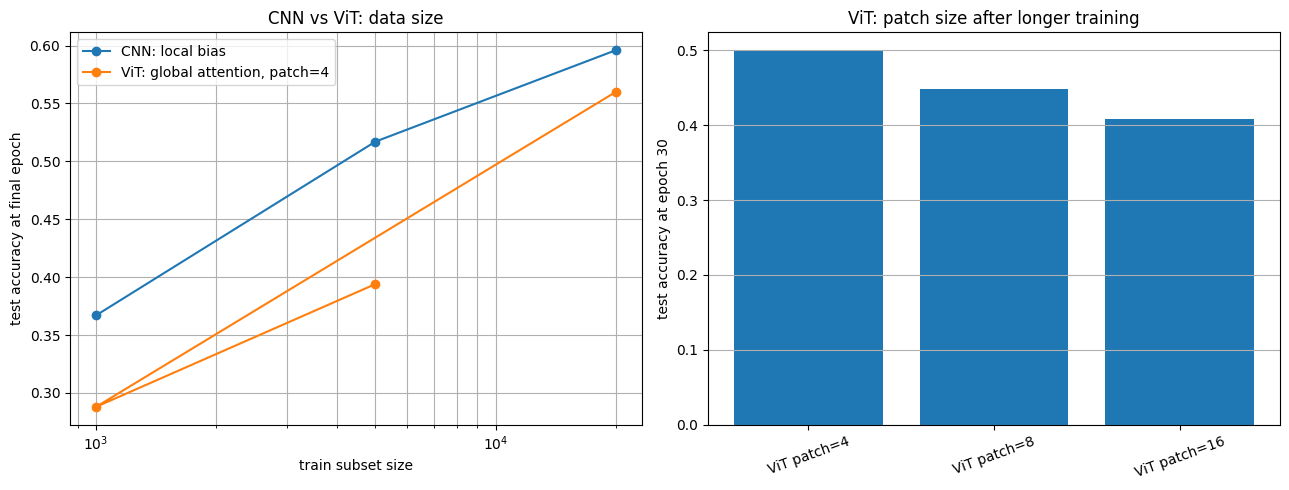

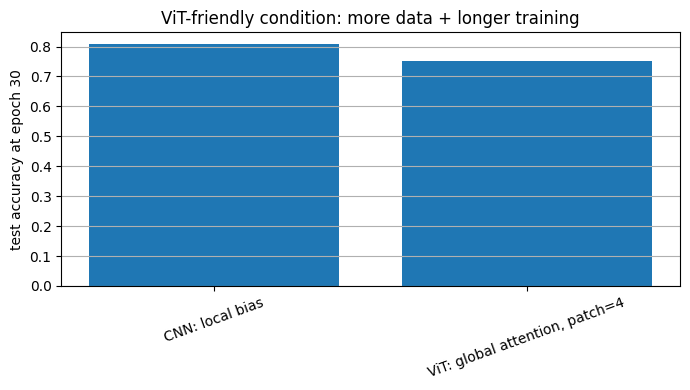

In [85]:
def make_local_cifar10_loaders(train_size, test_size=1000, batch_size=128, seed=42):
    exp_train_dataset = LocalCIFAR10(cifar10_root / "train.csv", cifar10_images, transform=transform_train)
    exp_test_dataset = LocalCIFAR10(cifar10_root / "test.csv", cifar10_images, transform=transform_test)

    exp_train_indices = balanced_subset_indices(exp_train_dataset.items, train_size, seed=seed)
    exp_test_indices = balanced_subset_indices(exp_test_dataset.items, test_size, seed=seed)

    exp_train_subset = Subset(exp_train_dataset, exp_train_indices)
    exp_test_subset = Subset(exp_test_dataset, exp_test_indices)

    exp_train_loader = DataLoader(
        exp_train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    exp_test_loader = DataLoader(
        exp_test_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    return exp_train_loader, exp_test_loader


condition_train_sizes = [1000, 5000, 20000]
condition_epochs = epochs
patch_epochs = max(epochs * 3, 30)
vit_friendly_train_size = 50000
vit_friendly_epochs = max(epochs * 3, 30)

condition_model_factories = {
    "CNN: local bias": lambda: TinyCNN(width=32),
    "ViT: global attention, patch=4": lambda: TinyViT(embed_dim=64, depth=4, num_heads=4, patch_size=4),
}

condition_plan = pd.DataFrame([
    {
        "scenario": "small_data" if train_size == min(condition_train_sizes) else "more_data",
        "train_subset_size": train_size,
        "epochs": condition_epochs,
        "model": model_name,
        "comparison": "CNN vs ViT as data size changes",
    }
    for train_size in condition_train_sizes
    for model_name in condition_model_factories
])

vit_patch_condition_plan = pd.DataFrame([
    {
        "scenario": "vit_patch_long",
        "train_subset_size": 5000,
        "epochs": patch_epochs,
        "model": f"ViT patch={patch_size}",
        "comparison": "ViT patch size sensitivity after longer training",
    }
    for patch_size in [4, 8, 16]
])

vit_friendly_plan = pd.DataFrame([
    {
        "scenario": "vit_friendly",
        "train_subset_size": vit_friendly_train_size,
        "epochs": vit_friendly_epochs,
        "model": model_name,
        "comparison": "CNN vs ViT with more data and longer training",
    }
    for model_name in condition_model_factories
])

full_condition_plan = pd.concat([condition_plan, vit_patch_condition_plan, vit_friendly_plan], ignore_index=True)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(full_condition_plan)

run_condition_experiment = True
run_vit_friendly_experiment = True

if run_condition_experiment:
    condition_histories = []

    for train_size in condition_train_sizes:
        exp_train_loader, exp_test_loader = make_local_cifar10_loaders(
            train_size=train_size,
            test_size=test_subset_size,
            batch_size=batch_size,
            seed=seed,
        )
        scenario = "small_data" if train_size == min(condition_train_sizes) else "more_data"
        for model_name, model_factory in condition_model_factories.items():
            history = fit_model(
                f"{model_name} train={train_size}",
                model_factory(),
                epochs=condition_epochs,
                train_loader_arg=exp_train_loader,
                test_loader_arg=exp_test_loader,
            )
            history["scenario"] = scenario
            history["base_model"] = model_name
            history["train_subset_size"] = train_size
            history["comparison"] = "CNN vs ViT as data size changes"
            condition_histories.append(history)

    patch_train_loader, patch_test_loader = make_local_cifar10_loaders(
        train_size=5000,
        test_size=test_subset_size,
        batch_size=batch_size,
        seed=seed,
    )
    for patch_size in [4, 8, 16]:
        model_name = f"ViT patch={patch_size}"
        history = fit_model(
            model_name,
            TinyViT(embed_dim=64, depth=4, num_heads=4, patch_size=patch_size),
            epochs=patch_epochs,
            train_loader_arg=patch_train_loader,
            test_loader_arg=patch_test_loader,
        )
        history["scenario"] = "vit_patch_long"
        history["base_model"] = model_name
        history["train_subset_size"] = 5000
        history["comparison"] = "ViT patch size sensitivity after longer training"
        condition_histories.append(history)

    if run_vit_friendly_experiment:
        friendly_train_loader, friendly_test_loader = make_local_cifar10_loaders(
            train_size=vit_friendly_train_size,
            test_size=test_subset_size,
            batch_size=batch_size,
            seed=seed,
        )
        for model_name, model_factory in condition_model_factories.items():
            history = fit_model(
                f"{model_name} friendly train={vit_friendly_train_size}",
                model_factory(),
                epochs=vit_friendly_epochs,
                train_loader_arg=friendly_train_loader,
                test_loader_arg=friendly_test_loader,
            )
            history["scenario"] = "vit_friendly"
            history["base_model"] = model_name
            history["train_subset_size"] = vit_friendly_train_size
            history["comparison"] = "CNN vs ViT with more data and longer training"
            condition_histories.append(history)

    condition_results = pd.concat(condition_histories, ignore_index=True)
    final_by_run = condition_results.sort_values("epoch").groupby("model").tail(1).copy()

    data_size_final = final_by_run[
        final_by_run["comparison"] == "CNN vs ViT as data size changes"
    ].copy()
    data_size_pivot = data_size_final.pivot_table(
        index="train_subset_size",
        columns="base_model",
        values="test_acc",
        aggfunc="first",
    )
    data_size_model_columns = data_size_pivot.columns.tolist()
    data_size_pivot["winner"] = data_size_pivot[data_size_model_columns].idxmax(axis=1)
    data_size_pivot["accuracy_gap"] = (
        data_size_pivot[data_size_model_columns].max(axis=1)
        - data_size_pivot[data_size_model_columns].min(axis=1)
    )

    patch_final = final_by_run[
        final_by_run["comparison"] == "ViT patch size sensitivity after longer training"
    ].copy()
    patch_winner = patch_final.loc[patch_final["test_acc"].idxmax(), ["base_model", "test_acc"]]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for model_name, group in data_size_final.groupby("base_model"):
        axes[0].plot(group["train_subset_size"], group["test_acc"], marker="o", label=model_name)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("train subset size")
    axes[0].set_ylabel("test accuracy at final epoch")
    axes[0].set_title("CNN vs ViT: data size")
    axes[0].grid(True, which="both")
    axes[0].legend()

    axes[1].bar(patch_final["base_model"], patch_final["test_acc"])
    axes[1].set_ylabel(f"test accuracy at epoch {patch_epochs}")
    axes[1].set_title("ViT: patch size after longer training")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].grid(True, axis="y")
    plt.tight_layout()

    if run_vit_friendly_experiment:
        friendly_final = final_by_run[
            final_by_run["comparison"] == "CNN vs ViT with more data and longer training"
        ].copy()
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(friendly_final["base_model"], friendly_final["test_acc"])
        ax.set_ylabel(f"test accuracy at epoch {vit_friendly_epochs}")
        ax.set_title("ViT-friendly condition: more data + longer training")
        ax.tick_params(axis="x", rotation=20)
        ax.grid(True, axis="y")
        plt.tight_layout()

    interpretation_rows = []
    small_size = min(condition_train_sizes)
    largest_size = max(condition_train_sizes)
    small_winner = data_size_pivot.loc[small_size, "winner"]
    largest_winner = data_size_pivot.loc[largest_size, "winner"]
    gap_change = data_size_pivot.loc[small_size, "accuracy_gap"] - data_size_pivot.loc[largest_size, "accuracy_gap"]
    interpretation_rows.append({
        "question": "少ないデータではどちらが強いか",
        "answer_from_result": small_winner,
        "how_to_read": "CNNが勝つなら局所的な帰納バイアスが効いている。ViTが勝つならこの設定では全体関係やモデル容量が有利に働いている。",
    })
    interpretation_rows.append({
        "question": "データを増やすとViTは有利になるか",
        "answer_from_result": largest_winner,
        "how_to_read": "最大データ量でViTが勝つ，またはCNNとの差が縮むなら，データ量がViTに効いている可能性がある。差が縮まらない場合は，このTinyViTをゼロから学習する条件がまだViTに厳しい。",
    })
    interpretation_rows.append({
        "question": "ViTではどのpatch sizeが良いか",
        "answer_from_result": patch_winner["base_model"],
        "how_to_read": f"patch size比較はepoch={patch_epochs}まで学習して読む。小さいpatchが勝つなら細部情報が重要。大きいpatchが勝つなら粗い表現でも十分，または単純なトークン構造が効いている。",
    })

    if run_vit_friendly_experiment:
        friendly_winner = friendly_final.loc[friendly_final["test_acc"].idxmax(), "base_model"]
        interpretation_rows.append({
            "question": "ViT向け条件でCNNとの差はどう変わるか",
            "answer_from_result": friendly_winner,
            "how_to_read": "ViTが改善する，または差が縮むなら，ViTがデータ量と長い学習の恩恵を受けることが可視化できている。まだ負ける場合でも，現代のViTとの差は事前学習とモデル規模にある。",
        })

    interpretation = pd.DataFrame(interpretation_rows)
    interpretation["small_to_large_gap_change"] = gap_change

    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None):
        display(final_by_run)
        display(data_size_pivot.reset_index())
        display(interpretation)
else:
    print("Set run_condition_experiment = True to train the condition-based comparison.")
    print(f"Patch size comparison will use patch_epochs={patch_epochs} when enabled.")
    print("Set run_vit_friendly_experiment = True as well to run the longer, more-data ViT-friendly comparison.")


## 16. まとめ

### この実験で切り分けること

このノートブックでは，CNNとViTの優劣を1つの精度だけで決めるのではなく，条件を変えて比較します。

- 少ないデータでCNNが強いなら，局所的な畳み込み構造がデータ効率に効いていると考えられる
- データ量を増やしたときにViTの精度が伸びる，またはCNNとの差が縮むなら，ViTがデータ量の恩恵を受けていると考えられる
- patch sizeを長めに学習して比べることで，未収束のばらつきではなく，トークン数と情報の粗さの影響を見やすくなる

### CNNが強くなりやすい場面

- 学習データが少ない
- 画像の局所的な形，エッジ，模様が重要
- ゼロから学習する
- 計算資源や学習時間が限られている

### ViTが強くなりやすい場面

- 学習データが多い，または大規模データで事前学習してから使う
- モデルサイズを大きくし，長く学習できる
- 離れた領域同士の関係が重要
- downstream taskへ転移学習する

### 今回の結果がViTに厳しく見える理由

この教材のTinyViTは，CIFAR-10上でゼロから学習しています。これは現代のViTが強い典型条件とはかなり違います。上の「なぜViTは大規模な事前学習で強くなるのか」で見たように，ViTは大量のデータから視覚表現そのものを学ぶことで強みが出ます。実際によく使われるViTは，ImageNet規模以上のデータで事前学習され，より大きなモデルとして，長いスケジュールで学習されることが多いです。

したがって，このノートブックでViTがCNNに大きく負ける場合でも，「ViTが一般に弱い」という意味ではありません。より正確には，「小規模データでゼロから学習する条件では，CNNの局所的な帰納バイアスが非常に強い」という結果です。

`run_vit_friendly_experiment = True` にすると，多めのデータ・長めの学習というViT寄りの条件を追加できます。そこでViTの精度が伸びる，またはCNNとの差が縮むなら，ViTがスケールや長い学習の恩恵を受けることを実験として確認できます。
